In [60]:
from py_experimenter.experimenter import PyExperimenter
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns


In [61]:
FIRST_VERSION_DATA_PATH = "plain_data/first_version_table.csv"
FIRST_VERSION_LOG_PATH = "plain_data/first_version_logtable.csv"
UPDATED_DATA_PATH = "plain_data/updated_table.csv"
UPDATED_LOG_PATH = "plain_data/updated_logtable.csv"
REAL_PREDICTION_DATA_PATH = "plain_data/real_prediction_table.csv"
REAL_PREDICTION_LOG_PATH = "plain_data/real_prediction_logtable.csv"


# Get Data

In [62]:
update_data = False

In [63]:
def get_data(table_name:str, update_data) -> [pd.DataFrame, pd.DataFrame]:
    if update_data:
        experimenter = PyExperimenter(experiment_configuration_file_path="conf/experiment_config.yml",
                                database_credential_file_path="conf/database_credentials.yml",
                                table_name=table_name)
        main_table = experimenter.get_table()
        log_table = experimenter.get_logtable("sh_iterations")

        main_table.to_csv(f"plain_data/{table_name}_table.csv", index=False)
        log_table.to_csv(f"plain_data/{table_name}_logtable.csv", index=False)
    else:
        main_table = pd.read_csv(f"plain_data/{table_name}_table.csv")
        log_table = pd.read_csv(f"plain_data/{table_name}_logtable.csv")

    return main_table, log_table


In [64]:
first_version_table, first_version_logtable = get_data("priorbai_experiments", update_data)
kernel_table, kernel_logtable = get_data("priorbai_experiments_lcbench_kernels", update_data)
real_prediction_table, real_prediction_logtable = get_data("priorbai_experiments_lcbench_kernels_ys", update_data)


# Display Head of Main Data

In [65]:
first_version_table.head()

,ID,run_id,num_arms,benchmark,seed,prior,performance_prior_std,sigma0,epsilon,delta,...,T_max,consumed_budget,remaining_arms,num_epsilon_optimal_arms,arm_id_selected,regret,epsilon_optimal,best_arm,end_date,error
0,1,__AUTO__,32,synthetic,0,uniform,0.01,0.01,0.01,0.05,...,32.0,96.0,1.0,1.0,0.0,0.00000,1.0,1.0,2026-01-24 08:41:01,NaN
1,2,__AUTO__,64,synthetic,0,uniform,0.01,0.01,0.01,0.05,...,64.0,224.0,1.0,2.0,0.0,0.00000,1.0,1.0,2026-01-24 08:33:37,NaN
2,3,__AUTO__,128,synthetic,0,uniform,0.01,0.01,0.01,0.05,...,128.0,512.0,1.0,2.0,0.0,0.00000,1.0,1.0,2026-01-24 08:41:00,NaN
3,4,__AUTO__,256,synthetic,0,uniform,0.01,0.01,0.01,0.05,...,256.0,1152.0,1.0,2.0,0.0,0.00000,1.0,1.0,2026-01-24 08:25:16,NaN
4,5,__AUTO__,32,lcbench,0,uniform,0.01,0.01,0.01,0.05,...,52.0,96.0,1.0,3.0,16.0,0.10709,0.0,0.0,2026-01-24 08:37:24,NaN


In [66]:
first_version_logtable.sort_values("experiment_id").head()

,ID,experiment_id,timestamp,iteration,num_arms,best_arm_included,budget_spent_so_far,N_stop
54020,54021,1,2026-01-24 08:41:00,4,2,1,96.0,3.026242e+06
54007,54008,1,2026-01-24 08:40:59,2,8,1,64.0,1.281531e+07
54016,54017,1,2026-01-24 08:41:00,3,4,1,80.0,6.407575e+06
53932,53933,1,2026-01-24 08:40:59,0,32,1,32.0,5.131354e+07
53946,53947,1,2026-01-24 08:40:59,1,16,1,48.0,2.563061e+07


# Merge DataFrames

In [67]:
def merge_dataframes(main_df: pd.DataFrame, log_df: pd.DataFrame, ) -> pd.DataFrame:
    return main_df.merge(log_df, left_on="ID", right_on="experiment_id", how="left")

merged_first_version = merge_dataframes(first_version_table, first_version_logtable)
merged_kernel = merge_dataframes(kernel_table, kernel_logtable)
merged_real_prediction = merge_dataframes(real_prediction_table, real_prediction_logtable)

# Evaluate How often we stop early

In [68]:
def create_table_summary(merged_df: pd.DataFrame) -> pd.DataFrame:
    return merged_df.groupby("prior").agg(
        avg_consumed_budget=pd.NamedAgg(column="consumed_budget", aggfunc="mean"),
        std_consumed_budget=pd.NamedAgg(column="consumed_budget", aggfunc="std"),
        avg_regret=pd.NamedAgg(column="regret", aggfunc="mean"),
        std_regret=pd.NamedAgg(column="regret", aggfunc="std"),
    ).reset_index()

In [69]:
synthethic_first_table_overview = create_table_summary(merged_first_version[merged_first_version["benchmark"] == "synthetic"])
lcbench_first_table_overview = create_table_summary(merged_first_version[merged_first_version["benchmark"] == "lcbench"])
lcbench_kernel_table_overview = create_table_summary(merged_kernel)
lcbench_real_prediction_table_overview = create_table_summary(merged_real_prediction)

In [70]:
synthethic_first_table_overview

,prior,avg_consumed_budget,std_consumed_budget,avg_regret,std_regret
0,indicator,651.060998,433.969586,0.000119,0.003582
1,inverse_rank,562.461538,419.437576,0.000282,0.006482
2,performance,573.806950,433.765342,0.000156,0.004619
3,rank,120.226290,85.854409,0.000000,0.000000
4,uniform,562.461538,419.437576,0.000163,0.004406


In [71]:
lcbench_first_table_overview

,prior,avg_consumed_budget,std_consumed_budget,avg_regret,std_regret
0,indicator,534.194626,398.206452,0.063100,0.066167
1,inverse_rank,552.832444,415.586214,0.065126,0.070116
2,performance,501.354611,378.162147,0.060545,0.060425
3,rank,487.502598,368.265175,0.063790,0.070717
4,uniform,539.642801,397.872506,0.061939,0.066998


In [72]:
lcbench_kernel_table_overview

,prior,avg_consumed_budget,std_consumed_budget,avg_regret,std_regret
0,indicator,517.594545,379.776727,0.123298,0.114353
1,inverse_rank,553.186613,410.647483,0.125551,0.122499
2,performance,488.992894,366.422664,0.119780,0.114276
3,rank,481.549028,362.984950,0.122516,0.112311
4,uniform,522.536315,382.114613,0.121689,0.116263


In [73]:
lcbench_real_prediction_table_overview

,prior,avg_consumed_budget,std_consumed_budget,avg_regret,std_regret
0,indicator,527.539159,393.919674,0.029509,0.048983
1,inverse_rank,547.308917,411.674006,0.050770,0.084018
2,performance,508.599287,385.263701,0.028647,0.047153
3,rank,474.964061,357.326774,0.029413,0.049134
4,uniform,537.984798,397.019443,0.027660,0.046899


# Plot Perofmrance and consumed budget

In [74]:
def plot_performance_and_budget(merged_df: pd.DataFrame, benchmark_name: str):
    # create 2 subfigures horizontally
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # Create boxplot for regret
    sns.boxplot(data=merged_df[merged_df["benchmark"] == benchmark_name], x="prior", y="regret", ax=ax[0])
    ax[0].set_title(f"Regret Distribution for {benchmark_name}")
    ax[0].set_ylabel("Regret")
    ax[0].set_xlabel("Prior")

    # Create boxplot for consumed budget
    sns.boxplot(data=merged_df[merged_df["benchmark"] == benchmark_name], x="prior", y="consumed_budget", ax=ax[1])
    ax[1].set_title(f"Consumed Budget Distribution for {benchmark_name}")
    ax[1].set_ylabel("Consumed Budget")
    ax[1].set_xlabel("Prior")
    fig.tight_layout()
    fig.show()

/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_66599/991954561.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


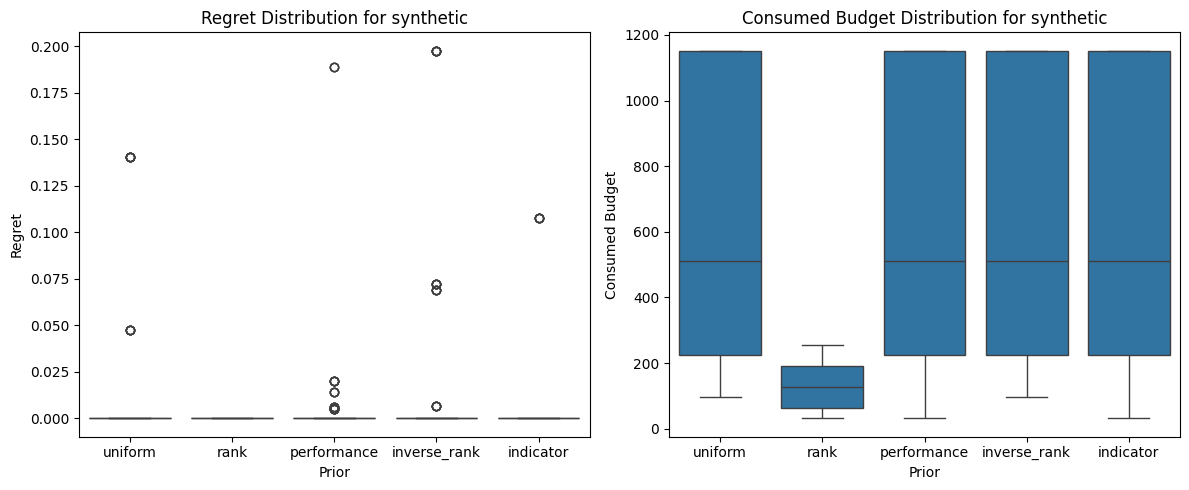

In [75]:
plot_performance_and_budget(merged_first_version, "synthetic")

/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_66599/991954561.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


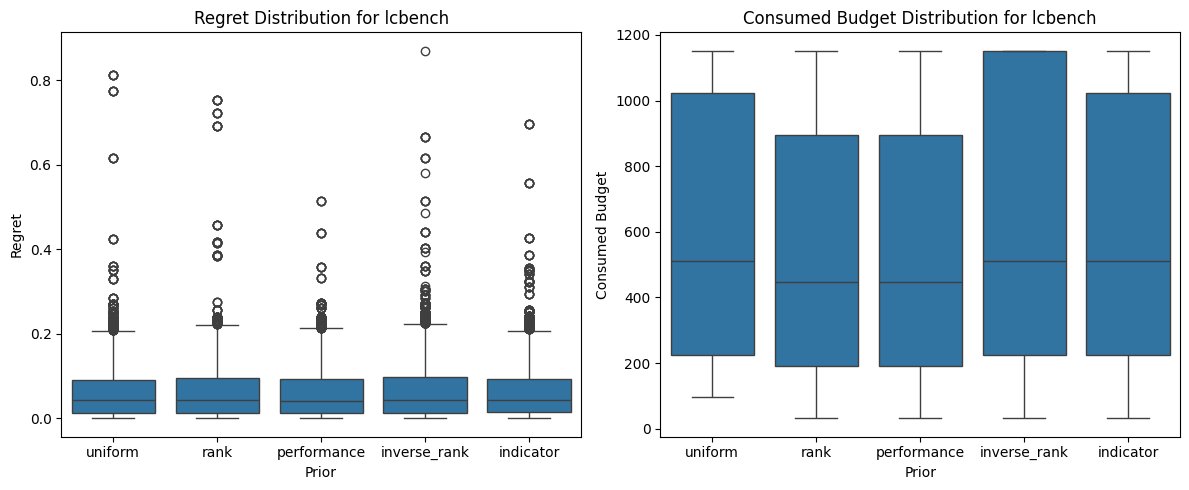

In [76]:
plot_performance_and_budget(merged_first_version, "lcbench")

/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_66599/991954561.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


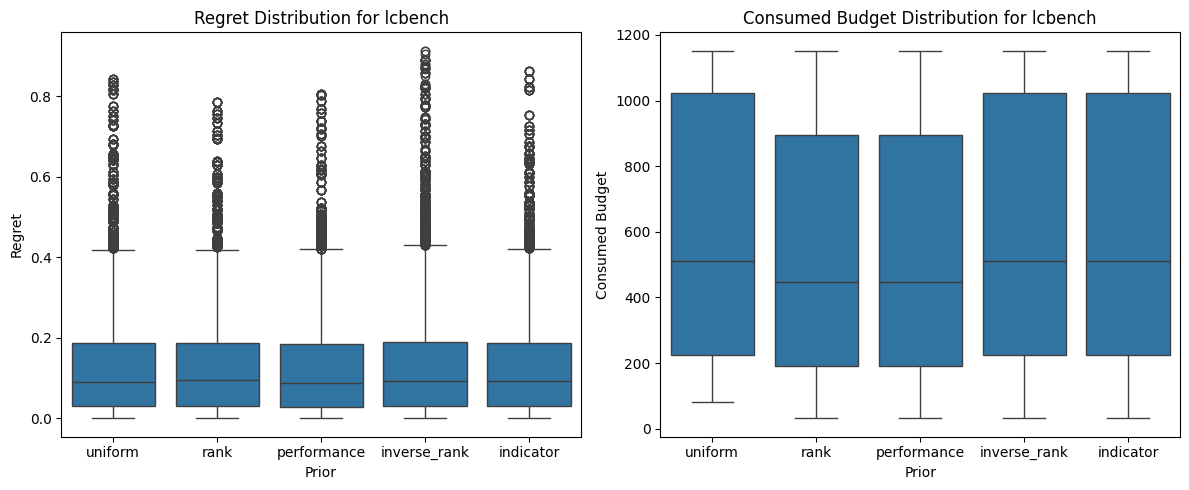

In [77]:
plot_performance_and_budget(merged_kernel, "lcbench")

/var/folders/3w/xg6_gz354xg5vfw2z0tx7prm0000gn/T/ipykernel_66599/991954561.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


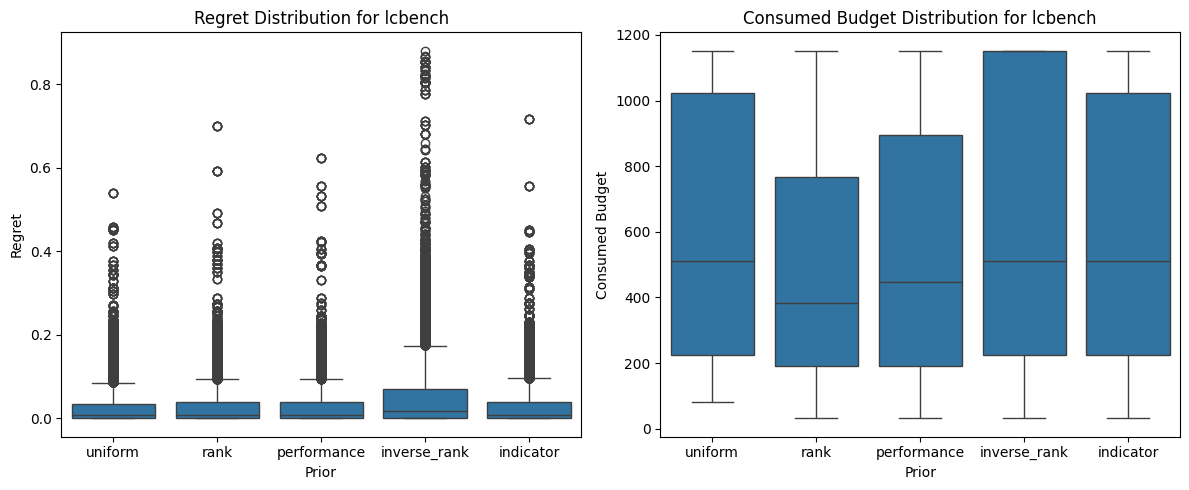

In [82]:
plot_performance_and_budget(merged_real_prediction, "lcbench")